# **Implementación del caso de 5 Qubits**

In [18]:
%load_ext autoreload
%autoreload 2

import modules
from modules.Schnorr_QAOA import SchnorrAlgQAOA


import numpy as np
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
seed = 99

In [20]:
N5 = 48567227

In [21]:
fiveQubit = SchnorrAlgQAOA(N5, 4, 1, seed)

El numero de bits de N = 48567227 es m = 26
La dimension del reticulo que vamos a tratar es n = 5
La cota smooth que vamos a tomar: 25


In [22]:
B5, t5 = fiveQubit.generate_cvp(10)
print(f'B5 = \n{B5}')
print(f't5 = \n{t5}')

B5 = 
[ 2 0 0 0 0  6931 ]
[ 0 1 0 0 0 10986 ]
[ 0 0 3 0 0 16094 ]
[ 0 0 0 2 0 19459 ]
[ 0 0 0 0 1 23979 ]
t5 = 
(0, 0, 0, 0, 0, 176985)


In [23]:
D5, b5_op, res5_vector, sign_step5, w5, dist5 = fiveQubit.babai_algorithm(B5, t5, delta = 0.75)
print(f'D5 = \n{D5}\n')
print(f'b5_op = \n{b5_op}\n')
print(f'res5_vector = \n{res5_vector}\n')
print(f'sign_step5 = \n{sign_step5}\n')
print(f'w5 = \n{w5}\n')
print(f'dist5 = \n{dist5}\n')

D5 = 
[  6 -4  6  4 -2  -3 ]
[ -8 -3  6 -2  2   5 ]
[  2 11  3  0 -6  -3 ]
[ -4 -5  0 12 -2   4 ]
[ -4 -3 -3  4  1 -17 ]

b5_op = 
[     2      4      9      8      0 176993]

res5_vector = 
[-2 -4 -9 -8  0 -8]

sign_step5 = 
[-1 -1 -1 -1  1]

w5 = 
(-3092, -354, -1837, 3883, -8732)

dist5 = 
15.132745950421556



In [24]:
qubo5 = fiveQubit.define_qubo(D5, res5_vector, sign_step5)
print(qubo5.prettyprint())
Hc5, offset5 = fiveQubit.define_hamiltonian(qubo5)
print(f'Offset = {offset5}')
print(f'Hamiltonian = \n{Hc5}')

Problem name: quboProblem

Minimize
  117*z_0^2 - 54*z_0*z_1 + 14*z_0*z_2 + 72*z_0*z_3 - 70*z_0*z_4 + 142*z_1^2
  - 116*z_1*z_2 + 78*z_1*z_3 + 136*z_1*z_4 + 179*z_2^2 - 126*z_2*z_3
  + 10*z_2*z_4 + 205*z_3^2 - 18*z_3*z_4 + 340*z_4^2 - 116*z_0 - 100*z_1
  - 102*z_2 - 200*z_3 - 302*z_4 + 229

Subject to
  No constraints

  Binary variables (5)
    z_0 z_1 z_2 z_3 z_4

Offset = 292.0
Hamiltonian = 
SparsePauliOp(['IIIIZ', 'IIIZI', 'IIZII', 'IZIII', 'ZIIII', 'IIIZZ', 'IIZIZ', 'IZIIZ', 'ZIIIZ', 'IIZZI', 'IZIZI', 'ZIIZI', 'IZZII', 'ZIZII', 'ZZIII'],
              coeffs=[  9. +0.j, -32. +0.j,  16. +0.j,  -4. +0.j, -33.5+0.j, -13.5+0.j,
   3.5+0.j,  18. +0.j, -17.5+0.j, -29. +0.j,  19.5+0.j,  34. +0.j,
 -31.5+0.j,   2.5+0.j,  -4.5+0.j])


In [25]:
circuit5 = fiveQubit.construct_circuit(Hc5, reps= 1)
print(circuit5.decompose(reps = 2))

     ┌────────────┐ ┌─────────────┐                                »
q_0: ┤ U(π/2,0,π) ├─┤ Rz(18*γ[0]) ├───■────────────────■───────────»
     ├────────────┤┌┴─────────────┴─┐ │ZZ((-27)*γ[0])  │           »
q_1: ┤ U(π/2,0,π) ├┤ Rz((-64)*γ[0]) ├─■────────────────┼───────────»
     ├────────────┤└┬─────────────┬─┘                  │ZZ(7*γ[0]) »
q_2: ┤ U(π/2,0,π) ├─┤ Rz(32*γ[0]) ├────────────────────■───────────»
     ├────────────┤┌┴─────────────┴┐                               »
q_3: ┤ U(π/2,0,π) ├┤ Rz((-8)*γ[0]) ├───────────────────────────────»
     ├────────────┤├───────────────┴┐                              »
q_4: ┤ U(π/2,0,π) ├┤ Rz((-67)*γ[0]) ├──────────────────────────────»
     └────────────┘└────────────────┘                              »
«                                                                   »
«q_0: ──────────────────■───────────────────────────■───────────────»
«                       │                           │               »
«q_1: ─■────────────────┼──────

In [26]:
x0 = np.asarray([0.0]*circuit5.num_parameters)
optParameters10 = fiveQubit.qaoa_algorithm(circuit5, Hc5, x0)

In [27]:
for param in optParameters10.items():
    print(f'{param[0].name} = {param[1]}')

β[0] = 0.38312632010753533
γ[0] = -0.010041903424999107


In [28]:
results5= fiveQubit.sample_from_parameters(circuit5, optParameters10, shots = 10_000)
print(len(results5))
for bitstring, count in results5.items():
    print(f"Bistring: {bitstring} -> Counts: {count}")

32
Bistring: 00111 -> Counts: 1011
Bistring: 01100 -> Counts: 1011
Bistring: 10001 -> Counts: 937
Bistring: 01110 -> Counts: 707
Bistring: 00000 -> Counts: 679
Bistring: 11101 -> Counts: 660
Bistring: 00011 -> Counts: 608
Bistring: 00001 -> Counts: 585
Bistring: 11100 -> Counts: 580
Bistring: 01111 -> Counts: 525
Bistring: 00110 -> Counts: 389
Bistring: 01000 -> Counts: 384
Bistring: 11000 -> Counts: 247
Bistring: 01101 -> Counts: 244
Bistring: 11001 -> Counts: 230
Bistring: 10111 -> Counts: 195
Bistring: 10101 -> Counts: 181
Bistring: 10000 -> Counts: 171
Bistring: 00010 -> Counts: 164
Bistring: 00101 -> Counts: 97
Bistring: 00100 -> Counts: 75
Bistring: 01001 -> Counts: 68
Bistring: 11111 -> Counts: 67
Bistring: 11010 -> Counts: 37
Bistring: 11011 -> Counts: 34
Bistring: 10010 -> Counts: 30
Bistring: 10100 -> Counts: 18
Bistring: 11110 -> Counts: 17
Bistring: 10011 -> Counts: 16
Bistring: 01011 -> Counts: 15
Bistring: 01010 -> Counts: 10
Bistring: 10110 -> Counts: 8


In [29]:
nD5 = fiveQubit.integer_to_matrix(D5)
vnew5 = fiveQubit.bitstring2latticeVectors(nD5, results5.keys(), sign_step5, b5_op)
for vect5 in vnew5:
    print(vect5)

[     0     -5      3      0      9 176975]
[     8     -4      0     10      4 176991]
[    -8      5      0      8      3 176979]
[    12      1      0     -2      6 176987]
[     2      4      9      8      0 176993]
[    -2     -3     -9     10      7 176977]
[     2      6      6      0      3 176972]
[    -2      1      6     12      1 176976]
[     2      0     -6      6      6 176994]
[     8     -2     -3      2      7 176970]
[     4     -2      6     -4      8 176992]
[    10      7      3     10     -2 176988]
[     4     11     -3      6      0 176991]
[     4     -7     -3     14      5 176974]
[     0      8     -6     10      1 176974]
[    -6     -1     -3     -4     11 176978]
[   -10     -6     -3      8      9 176982]
[    -4      8      3      4      2 176996]
[     6      9      9     -4      2 176989]
[    -4    -10      3     12      7 176979]
[     0     -7      6      8      6 176996]
[     6      4      0     14     -1 176971]
[     2      2     -9     -2    

In [30]:
distances5 = fiveQubit.get_distances(vnew5, t5)
for dist5 in distances5:
    print(dist5)

14.66287829861518
15.231546211727817
14.071247279470288
13.74772708486752
15.132745950421556
17.52141546793523
15.937377450509228
16.34013463836819
13.892443989449804
18.841443681416774
13.601470508735444
16.46207763315433
14.7648230602334
20.396078054371138
17.944358444926362
15.231546211727817
17.291616465790582
15.165750888103101
15.297058540778355
18.81488772222678
17.4928556845359
21.095023109728988
17.832554500127006
19.313207915827967
21.42428528562855
17.52141546793523
17.916472867168917
14.89966442575134
16.0312195418814
22.58317958127243
18.81488772222678
16.492422502470642


In [31]:
nB5 = fiveQubit.integer_to_matrix(B5)
uv_pairs5 = fiveQubit.vectors2uv_pairs(nB5, vnew5)
for pair5 in uv_pairs5:
    print(pair5)

[11789738455 243]
[3937140592 81]
[776562633 16]
[340139712 7]
[48620250 1]
[327520882997 6750]
[48514950 1]
[97060425 2]
[1215290846 25]
[2182563152 45]
[21435888100 441]
[5881105440 121]
[243045684 5]
[530529694772 10935]
[1212977997 25]
[285311670611 5880]
[5661432406091 116640]
[194500845 4]
[2381643000 49]
[11463230904895 236196]
[106337949025 2187]
[533655864 11]
[42443058438 875]
[83338451856 1715]
[8488175652 175]
[116712415215 2401]
[10503585169 216]
[416713664664 8575]
[9509900499 196]
[48498912 1]
[340122240 7]
[233436821409 4802]


In [32]:
sr_pairs5 = fiveQubit.uv_pairs2sr_pairs(uv_pairs5)
print(sr_pairs5)

[(11789738455, 243)]


In [33]:
probs5 = fiveQubit.get_probs(results5.values(), shots = 10_000)

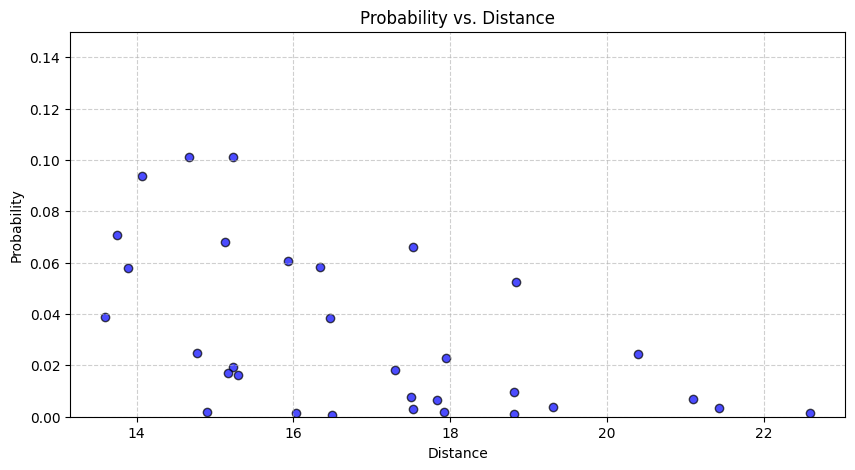

In [34]:
plt.figure(figsize=(10, 5))

# Creating the scatter plot
plt.scatter(distances5, probs5, color='blue', edgecolors='black', alpha=0.7)

# Adding labels and title
plt.xlabel('Distance')
plt.ylabel('Probability')
plt.title('Probability vs. Distance')

# Setting y-axis limit since you mentioned probs are <= 0.2
plt.ylim(0, 0.15) 

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()